# Model Family Search — ทดลองเพิ่มเติมสำหรับตัวอักษรไทย 72 คลาส

Notebook ใหม่ต่อจาก [01-model-search-lab](01-model-search-lab.ipynb): คัด **40 ตัวแทน** จากรายชื่อที่แนบมา + Custom CNN
เพื่อทดสอบคำถามทางสถาปัตยกรรม ใช้ trainer, preprocessing, metrics และ inference เดิม
ไม่ได้สมมติว่ารุ่นใหม่หรือใหญ่กว่าจะชนะ และยังไม่มีคะแนนจริงใน notebook นี้

**เส้นทาง:** ตรวจข้อมูล + รับ split เดิม → ตรวจชื่อ/weights/forward/backward → screening → ยืนยัน top candidates หลาย seed
→ optional ablation/HPO เฉพาะผู้ชนะ → export + error analysis + inference

เริ่มด้วย kernel `.venv` (`pip install -r requirements-training.txt`). ครั้งแรกใช้ `MODE="smoke"` ตรวจระบบโดยไม่ดาวน์โหลด weights;
เปลี่ยนเป็น `quick` เพื่อคัดกรอง 40 ตัว หรือ `full` เพื่อเพิ่ม budget. Real run ต้องมี split กลางจาก notebook เดิมแล้ว
Colab ต้อง clone/upload ทั้ง repo และตั้ง path; เก็บ output บน Drive เพื่อให้ผลไม่หายเมื่อ session จบ

## 1. เชื่อมกับสิ่งที่เรียน และตั้งสมมติฐานก่อนเห็นคะแนน

อ้างอิงเนื้อหา Week 2–7 ตาม [notebook ทบทวนใน repo](00-cnn-concepts-from-class.ipynb)
ไม่ได้อ้างว่าอาจารย์สอน architecture ทุกชื่อในตาราง: **CNN/loss/optimization/transfer learning เป็นแกนหลัก; attention และ token mixer เป็นส่วนต่อยอด**

| สิ่งที่เรียน | นำมาใช้ | คำถามที่การทดลองตอบ |
|---|---|---|
| RGB, resize, padding, normalization | RGB 224×224 รักษาสัดส่วน เติมขาว ใช้ ImageNet mean/std เดิม | ยังเก็บหัว/หาง/เส้นเล็กได้หรือไม่ ดู preview ก่อนเทรน |
| Conv / receptive field | DenseNet, Res2Net, InceptionNeXt, HRNet | การใช้ feature ซ้ำและหลาย scale ช่วยคู่คลาสคล้ายกันหรือไม่ |
| Activation / pooling / dense | Custom CNN: Conv→BN→ReLU→Pool→GAP→Linear | ได้ baseline ที่อธิบายทุกชั้นเองได้ |
| Backpropagation / optimizer / learning rate | CrossEntropy รับ logits, AdamW, LR ต่ำตอน unfreeze | features เดิมปรับเข้ากับตัวอักษรได้โดยไม่เปลี่ยนเร็วเกินไปหรือไม่ |
| Transfer learning | freeze backbone 2 epochs แล้ว fine-tune ทุกชั้น | pretrained recipe ใดปรับเข้ากับงานนี้ได้ดีภายใต้งบเดียวกัน |
| Regularization / validation | dropout, weight decay, early stopping, split เดิม | ลด overfit และไม่เลือก checkpoint จาก train accuracy |
| Imbalance / metrics | macro F1 หลัก, accuracy + minimum recall ประกอบ | โมเดลเก่งทุกคลาสหรือเฉพาะคลาสใหญ่ |
| ส่วนต่อยอด: attention / token mixing | Swin, ViT, MobileViT, PoolFormer | ความสัมพันธ์ระหว่างส่วนของตัวอักษรช่วยเมื่อเทียบกับ local convolution หรือไม่ |

เหตุผลทุกแถวเป็น **สมมติฐาน**: ต้องดูผลจริงและ confusion pairs จึงสรุปได้
โมเดล + pretrained weights เป็นหน่วยทดลอง: ViT/DeiT หรือ ConvNeXt/ConvNeXtV2 ไม่ใช่การแยก architecture effect บริสุทธิ์
เพราะ pretraining data, objective, distillation และขนาดต่างกัน แม้ downstream recipe คงที่

In [1]:
from pathlib import Path
import sys

MODE = "quick"  # ใช้ข้อมูลจริง; smoke ใช้เฉพาะตรวจระบบ, full ใช้เมื่อพร้อมรันนาน
POOL = "all"  # all = 40 ตัว; core = 20 ตัวก่อน; ใช้ all เมื่อต้องการลองทุกตัวที่คัดไว้
ONLY_FAMILIES = []  # เช่น ["DenseNet", "Res2Net"] เพื่อแบ่งงาน; [] = ทุกตัวใน POOL
INCLUDE_CUSTOM_CNN = True  # ให้ผู้รับผิดชอบ baseline เปิดเพียงคนเดียว; คนอื่นตั้ง False
REPO_PATH = ""
DATA_PATH = "data/raw"  # dataset root จริงที่ตรงกับ split กลาง (round2/, 72 คลาส, 62,707 ภาพ)
SPLIT_PATH = ""  # ว่าง = data/splits; real run ไม่สร้างหรือเขียน split กลางใหม่
OUTPUT_ROOT = ""  # ว่าง = results/model_family_search; คนละโฟลเดอร์หากรันพร้อมกัน
EXPECTED_CLASSES = 72
LABEL_LEVEL = 1
SEED = 42
DEVICE = "auto"
IMAGE_SIZE = 224
BATCH_SIZE = 32  # OOM: ลดสำหรับทุกตัวแล้วรันทั้งรอบใหม่ ห้ามลดเฉพาะผู้แพ้
PAD_VALUE = 255
TOP_K = 3
CONFIRM_SEEDS = (42, 123)
RUN_CONFIRMATION = True
RUN_HPO = False  # เปิดหลังเลือก family แล้ว; ไม่จูน 40 ตัวพร้อมกัน
ALLOW_PARTIAL = False  # ไม่ประกาศผู้ชนะครบ pool หากมี candidate ล้มเหลว

In [2]:
import gc
import importlib.metadata
import json
import shutil
from dataclasses import asdict, replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
from IPython.display import display
from PIL import Image

folders = [Path(REPO_PATH).expanduser()] if REPO_PATH else [Path.cwd(), *Path.cwd().parents]
project_dir = next((p.resolve() for p in folders if (p / "src/train.py").is_file()), None)
if project_dir is None:
    raise FileNotFoundError("ตั้ง REPO_PATH เป็น repo ที่มี src/train.py")
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))
from src.audit import DEFAULT_EXTENSIONS, audit_dataset
from src.paths import configured_data_dir
from src.split import fingerprint, prepare_split, read_rows
from src.train import TrainConfig, build_model, choose_device, fit, load_split, save_json, make_transform
from src.search import config_from_receipt, rank_runs, run_ablations, tune, confirm
from src.inference import Predictor

assert MODE in {"smoke", "quick", "full"}
assert POOL in {"core", "all"}
assert TOP_K >= 1 and CONFIRM_SEEDS and len(set(CONFIRM_SEEDS)) == len(CONFIRM_SEEDS)
budget = {"smoke": (2, 2), "quick": (6, 20), "full": (12, 30)}[MODE]
results_dir = Path(OUTPUT_ROOT).expanduser().resolve() if OUTPUT_ROOT else project_dir / "results/model_family_search"
results_dir.mkdir(parents=True, exist_ok=True)
print("torch", torch.__version__, "timm", timm.__version__, "device", choose_device(DEVICE))

/Users/thawaree.kha/kmitl-deeplearn-project1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.14.0 timm 1.0.29 device mps


## 2. Candidate table: เลือกตัวแทน ไม่ไล่ทุกขนาด

`core` มี 20 ตัวที่ครอบคลุมแนวคิดหลัก ส่วน `all` เพิ่มอีก 20 ตัวเพื่อทดสอบแนวคิดย่อย/ประสิทธิภาพ
ทุกแถวเป็น RUN candidate; จะ RUN ได้จริงต่อเมื่อ environment มี pretrained weights และผ่าน preflight
`cost` เป็นระดับคร่าว ๆ สำหรับวางแผน ไม่ใช่เวลา benchmark; parameter count วัดจริงก่อนฝึก

ตรวจชื่อกับ registry ของเครื่องและ **ล็อก weight tag** ลง config ทุก run ตาม [timm Quickstart](https://huggingface.co/docs/timm/quickstart)
ไม่มี fallback เป็น random weights หากดาวน์โหลดไม่สำเร็จ ไม่มีการเลือกชื่ออื่นเงียบ ๆ

ตรวจ offline ระหว่างพัฒนา: `torch 2.14.0`, `timm 1.0.29`, CPU, input 224, output 72 คลาส
ตัวแทนสุดท้ายทั้ง 40 ตัวผ่าน forward/backward โดยไม่ดาวน์โหลด weights; smoke ทดสอบตั้งแต่ฝึกจน export/reload
นี่ไม่ใช่ผลการฝึกข้อมูลจริง และยังไม่ยืนยันการดาวน์โหลด pretrained weights หรือ GPU memory ของ batch ที่ตั้งไว้

In [3]:
# family, timm model, group, tier, expected cost, hypothesis
CANDIDATES = [('ResNet',
  'resnet18',
  'CNN',
  'core',
  'low',
  'residual connection ช่วยส่ง gradient; เป็น control ที่เทียบกับผลเดิมได้'),
 ('ResNeXt',
  'resnext50_32x4d',
  'CNN',
  'core',
  'high',
  'grouped convolution เพิ่มทางเรียน feature เส้นหลายรูปแบบ'),
 ('DenseNet',
  'densenet121',
  'CNN',
  'core',
  'medium',
  'นำ feature ตื้นกลับมาใช้ ช่วยรักษาขอบ/เส้นเล็ก แต่ใช้ activation memory มาก'),
 ('Res2Net',
  'res2net50_26w_4s',
  'CNN',
  'core',
  'high',
  'หลาย receptive fields ใน block เดียว ทดสอบหัวตัวอักษรกับโครงร่างรวม'),
 ('ResNeSt',
  'resnest50d',
  'Attention CNN',
  'core',
  'high',
  'split attention เลือก feature branch ที่สำคัญต่อรูปตัวอักษร'),
 ('DLA',
  'dla34',
  'CNN',
  'extended',
  'medium',
  'รวม feature หลายระดับ ทดสอบ local strokes กับ global shape'),
 ('SE-ResNet',
  'seresnet50',
  'Attention CNN',
  'extended',
  'high',
  'channel attention ถ่วงน้ำหนัก feature ที่แยกคลาสได้'),
 ('ECA-ResNet',
  'ecaresnet26t',
  'Attention CNN',
  'extended',
  'medium',
  'channel attention แบบเบา เทียบประโยชน์กับต้นทุน SE'),
 ('EfficientNet',
  'efficientnet_b0',
  'Efficient CNN',
  'core',
  'low',
  'compound scaling ให้ reference ของ accuracy ต่อจำนวนพารามิเตอร์'),
 ('EfficientNetV2',
  'efficientnetv2_rw_s',
  'Efficient CNN',
  'core',
  'high',
  'fused blocks เป็นอีกทางเลือกความเร็วและ capacity; เทียบกับ B0'),
 ('RegNet',
  'regnety_032',
  'Efficient CNN',
  'core',
  'medium',
  'ออกแบบ width/depth อย่างเป็นระบบ เป็น control CNN ต่าง design'),
 ('ReXNet',
  'rexnet_100',
  'Efficient CNN',
  'core',
  'low',
  'จัด channel เพื่อลด bottleneck ของข้อมูลในโมเดลเล็ก'),
 ('MixNet',
  'mixnet_s',
  'Efficient CNN',
  'extended',
  'low',
  'mixed depthwise kernels ตรวจจับเส้นหลาย scale ด้วยโมเดลเล็ก'),
 ('MobileNetV2',
  'mobilenetv2_100',
  'Mobile CNN',
  'extended',
  'low',
  'inverted residual / linear bottleneck เชื่อม convolution ที่เรียนกับงานประหยัด compute'),
 ('MobileNetV3',
  'mobilenetv3_large_100',
  'Mobile CNN',
  'core',
  'low',
  'depthwise convolution + SE เป็น backup สำหรับ demo'),
 ('MobileNetV4',
  'mobilenetv4_conv_small',
  'Mobile CNN',
  'extended',
  'low',
  'universal inverted bottleneck เปรียบเทียบ mobile design รุ่นใหม่'),
 ('GhostNet',
  'ghostnet_100',
  'Mobile CNN',
  'extended',
  'low',
  'สร้าง feature เพิ่มด้วย cheap operations ทดสอบความซ้ำซ้อนของ channel'),
 ('MobileOne',
  'mobileone_s0',
  'Reparameterization',
  'extended',
  'low',
  'หลาย branch ตอนฝึก; ศึกษา trade-off แต่ notebook ยังไม่ fuse inference'),
 ('RepVGG',
  'repvgg_a0',
  'Reparameterization',
  'extended',
  'medium',
  'VGG-style conv พร้อม branch training อธิบายได้จาก convolution'),
 ('RepViT',
  'repvit_m1',
  'Reparameterization',
  'extended',
  'low',
  'mobile CNN ที่ปรับ block ตามแนวคิด ViT; weights มี distillation จึงเป็น recipe comparison'),
 ('ConvNeXt',
  'convnext_tiny',
  'Modern CNN',
  'core',
  'high',
  'large depthwise kernel + modern block ทดสอบ CNN ที่มองบริบทกว้างขึ้น'),
 ('ConvNeXtV2',
  'convnextv2_atto',
  'Modern CNN',
  'extended',
  'low',
  'GRN + FCMAE weights ในโมเดลเล็ก; แยกผล recipe และ capacity ไม่ได้ในรอบนี้'),
 ('InceptionNeXt',
  'inception_next_tiny',
  'Modern CNN',
  'core',
  'high',
  'แยก depthwise kernels หลายรูปแบบ อาจเหมาะเส้นแนวนอน/ตั้งและส่วนโค้ง'),
 ('FasterNet',
  'fasternet_t0',
  'Modern CNN',
  'extended',
  'low',
  'partial convolution ทดสอบความเร็วจริงแทนการสรุปจาก FLOPs'),
 ('StarNet',
  'starnet_s1',
  'Modern CNN',
  'extended',
  'low',
  'element-wise multiplication เพิ่ม feature interaction ในเครือข่ายเล็ก'),
 ('RDNet',
  'rdnet_tiny',
  'Modern CNN',
  'extended',
  'high',
  'modern dense connectivity เปรียบเทียบ feature reuse กับ DenseNet'),
 ('HRNet',
  'hrnet_w18_small_v2',
  'CNN',
  'core',
  'medium',
  'คง feature ความละเอียดสูงหลาย branch อาจช่วยแยกเส้นเล็กที่คล้ายกัน'),
 ('ViT',
  'vit_small_patch16_224',
  'Transformer',
  'core',
  'medium',
  'global attention ทดสอบรูปทรงรวม; patch 16 อาจเสียรายละเอียดเส้นเล็ก'),
 ('DeiT',
  'deit_small_patch16_224',
  'Transformer',
  'extended',
  'medium',
  'ViT ที่ใช้ training recipe อีกแบบ; รุ่นนี้ไม่ใช่ distilled head'),
 ('Swin-Transformer',
  'swin_tiny_patch4_window7_224',
  'Transformer',
  'core',
  'high',
  'window attention และ hierarchy รวม local strokes กับ global structure'),
 ('PVTv2',
  'pvt_v2_b1',
  'Transformer',
  'core',
  'medium',
  'pyramid features หลาย scale พร้อม overlapping patch embedding'),
 ('MaxViT',
  'maxvit_tiny_tf_224',
  'Hybrid',
  'extended',
  'high',
  'ผสม convolution กับ block/grid attention; คุ้มเป็นตัวแทน hybrid ที่หนักกว่า'),
 ('MobileViT',
  'mobilevit_xxs',
  'Hybrid',
  'core',
  'low',
  'ผสม local conv และ global attention แบบเล็กเพื่อลองบนงบจำกัด'),
 ('EdgeNeXt',
  'edgenext_xx_small',
  'Hybrid',
  'extended',
  'low',
  'ผสม conv กับ attention ให้ representation ที่กว้างขึ้นในโมเดลเล็ก'),
 ('FastViT',
  'fastvit_t8',
  'Hybrid',
  'extended',
  'low',
  'ผสม token mixing กับ reparameterization; ยังไม่อ้างความเร็วหลัง fuse'),
 ('TinyViT',
  'tiny_vit_5m_224',
  'Efficient Transformer',
  'core',
  'low',
  'attention แบบเล็ก แต่ distillation/22k weights ทำให้เป็น recipe comparison'),
 ('EfficientViT-MIT',
  'efficientvit_b0',
  'Efficient Transformer',
  'extended',
  'low',
  'multi-scale linear attention ทดสอบบริบทหลาย scale ด้วยต้นทุนต่ำ; เป็นส่วนต่อยอดจาก CNN'),
 ('PoolFormer',
  'poolformer_s12',
  'Token mixer',
  'core',
  'medium',
  'ใช้ pooling ผสม tokens ทดสอบว่าต้องมี attention เสมอหรือไม่'),
 ('ConvMixer',
  'convmixer_768_32',
  'Token mixer',
  'extended',
  'high',
  'แยก spatial/channel mixing ด้วย conv; ตัวนี้เล็กด้าน params แต่ฝึกอาจช้า'),
 ('CAFormer',
  'caformer_s18',
  'Token mixer',
  'core',
  'high',
  'ผสม convolution ช่วงตื้นกับ attention ช่วงลึกเทียบกับ PoolFormer')]
candidate_table = pd.DataFrame(CANDIDATES, columns=["family", "model", "group", "tier", "cost", "hypothesis"])
assert candidate_table.family.is_unique and candidate_table.model.is_unique
assert len(candidate_table.query("tier == 'core'")) == 20
display(candidate_table)

,family,model,group,tier,cost,hypothesis
0,ResNet,resnet18,CNN,core,low,residual connection ช่วยส่ง gradient; เป็น con...
1,ResNeXt,resnext50_32x4d,CNN,core,high,grouped convolution เพิ่มทางเรียน feature เส้น...
2,DenseNet,densenet121,CNN,core,medium,นำ feature ตื้นกลับมาใช้ ช่วยรักษาขอบ/เส้นเล็ก...
3,Res2Net,res2net50_26w_4s,CNN,core,high,หลาย receptive fields ใน block เดียว ทดสอบหัวต...
4,ResNeSt,resnest50d,Attention CNN,core,high,split attention เลือก feature branch ที่สำคัญต...
5,DLA,dla34,CNN,extended,medium,รวม feature หลายระดับ ทดสอบ local strokes กับ ...
6,SE-ResNet,seresnet50,Attention CNN,extended,high,channel attention ถ่วงน้ำหนัก feature ที่แยกคล...
7,ECA-ResNet,ecaresnet26t,Attention CNN,extended,medium,channel attention แบบเบา เทียบประโยชน์กับต้นทุ...
8,EfficientNet,efficientnet_b0,Efficient CNN,core,low,compound scaling ให้ reference ของ accuracy ต่...
9,EfficientNetV2,efficientnetv2_rw_s,Efficient CNN,core,high,fused blocks เป็นอีกทางเลือกความเร็วและ capaci...


### แล้วชื่ออื่นจาก Master List ไปไหน?

ตารางถัดไปครอบคลุม **ทุกชื่อจากไฟล์ Master List** ไม่ใช้คำว่า 120 architectures ที่ไม่ซ้ำกัน
RUN = มีตัวแทนใน 40 ตัว; LATER = เก็บไว้เมื่อมีคำถาม/งบเพิ่ม; SKIP = ไม่รวมใน architecture screening รอบนี้
ชื่อในไฟล์แนบไม่ใช่หลักฐานว่ามี implementation หรือ weights ที่ใช้ได้แล้ว โดยเฉพาะชื่อใหม่/vision-language encoder

DINO/MAE/CLIP คือวิธีหรือ ecosystem ของ pretraining ต้องแยกจาก family ของ backbone
รุ่น V2/V3 และชื่อ umbrella เช่น MetaFormer ก็ไม่ใช่จำนวน family อิสระทุกตัว
หากเพิ่มรอบ pretraining ให้ตรึง backbone/ขนาดแล้วเปลี่ยนเฉพาะ weights และทำตารางแยก

In [4]:
MASTER_FAMILIES = ['VGG',
 'ResNet',
 'ResNetV2',
 'ResNeXt',
 'DenseNet',
 'DPN',
 'DLA',
 'Res2Net',
 'ResNeSt',
 'InceptionV3',
 'InceptionV4',
 'InceptionResNetV2',
 'Xception',
 'VoVNet',
 'TResNet',
 'SelecSLS',
 'CSPNet',
 'SE-ResNet',
 'ECA-ResNet',
 'Selective-Kernel-Net',
 'ResNet-RS',
 'NF-ResNet',
 'EfficientNet',
 'EfficientNetV2',
 'MnasNet',
 'MixNet',
 'TinyNet',
 'FBNet',
 'ReXNet',
 'RegNet',
 'RegNetZ',
 'GPU-Efficient-Net',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNetV4',
 'MobileNetV5',
 'GhostNet',
 'GhostNetV2',
 'GhostNetV3',
 'MobileOne',
 'PP-LCNet',
 'PP-LCNetV2',
 'LCNet',
 'CPUBone',
 'RepVGG',
 'RepGhostNet',
 'RepViT',
 'ConvNeXt',
 'ConvNeXtV2',
 'InceptionNeXt',
 'FasterNet',
 'StarNet',
 'RDNet',
 'HRNet',
 'NFNet',
 'ViT',
 'DeiT',
 'DeiT-II',
 'DeiT-III',
 'BEiT',
 'BEiTV2',
 'BEiT3',
 'CaiT',
 'XCiT',
 'TNT',
 'CrossViT',
 'ConViT',
 'Visformer',
 'VOLO',
 'Swin-Transformer',
 'SwinV2',
 'Swin-S3',
 'PVT',
 'PVTv2',
 'PiT',
 'MViT',
 'MViTv2',
 'NesT',
 'Twins',
 'Hiera',
 'CoAtNet',
 'CoaT',
 'MaxViT',
 'DaViT',
 'GCViT',
 'FocalNet',
 'HaloNet',
 'Bottleneck-Transformer',
 'LambdaNet',
 'LeViT',
 'MobileViT',
 'MobileViTv2',
 'Next-ViT',
 'EdgeNeXt',
 'FastViT',
 'ViTamin',
 'TinyViT',
 'SHViT',
 'SwiftFormer',
 'EfficientFormer',
 'EfficientFormerV2',
 'EfficientViT-MIT',
 'EfficientViT-MSRA',
 'LowFormer',
 'EfficientViM',
 'MetaFormer',
 'PoolFormer',
 'ConvFormer',
 'CAFormer',
 'MLP-Mixer',
 'ResMLP',
 'gMLP',
 'ConvMixer',
 'Sequencer2D',
 'NASNet',
 'PNASNet',
 'Single-Path-NAS',
 'HardCoRe-NAS',
 'NaViT',
 'FlexiViT',
 'NaFlexViT',
 'EVA',
 'EVA-02',
 'EVA-CLIP',
 'RoPE-ViT',
 'Perception-Encoder',
 'EUPE-ViT',
 'EUPE-ConvNeXt',
 'TIPSv2',
 'DINO',
 'DINOv2',
 'DINOv3',
 'MAE',
 'I-JEPA',
 'AIM',
 'AIMv2',
 'CLIP',
 'SigLIP',
 'SigLIP2',
 'iFormer',
 'LingBot-Vision',
 'Gemma-Vision',
 'Qwen3-VL-ViT',
 'Qwen3.5-ViT',
 'Qwen3.8-ViT',
 'DeepSeek-V4-ViT',
 'DeepSeek-V4.1-ViT',
 'Sapiens2-ViT']
pretraining = set("DINO DINOv2 DINOv3 MAE I-JEPA AIM AIMv2 CLIP SigLIP SigLIP2 EVA EVA-02 EVA-CLIP Perception-Encoder EUPE-ViT EUPE-ConvNeXt TIPSv2".split())
emerging = set("MobileNetV5 CPUBone LowFormer EfficientViM iFormer LingBot-Vision Gemma-Vision Qwen3-VL-ViT Qwen3.5-ViT Qwen3.8-ViT DeepSeek-V4-ViT DeepSeek-V4.1-ViT Sapiens2-ViT".split())
heavy = set("VGG InceptionV3 InceptionV4 InceptionResNetV2 NFNet NASNet PNASNet BEiT BEiTV2 BEiT3 CaiT XCiT TNT VOLO".split())
flexible = {"NaViT", "FlexiViT", "NaFlexViT", "RoPE-ViT"}
selected_lookup = candidate_table.set_index("family")
coverage = []
for family in MASTER_FAMILIES:
    if family in selected_lookup.index:
        status, reason = "RUN", selected_lookup.loc[family, "hypothesis"]
    elif family in pretraining:
        status, reason = "SKIP", "แยกเป็น pretraining/encoder study ต้องควบคุม backbone และแหล่ง pretrain ก่อน"
    elif family in emerging:
        status, reason = "LATER", "ยังไม่ยืนยันชื่อ/weights/API ใน environment นี้; ยังไม่เพิ่มความเสี่ยงก่อนมี baseline"
    elif family in heavy:
        status, reason = "LATER", "ต้นทุน/ความซับซ้อนเพิ่ม; มีตัวแทนแนวคิดใกล้เคียงในชุด RUN แล้ว"
    elif family in flexible:
        status, reason = "SKIP", "เน้น position/resolution flexibility ซึ่งไม่ใช่คำถามหลักของ fixed 224 benchmark นี้"
    elif family in {"EfficientFormer", "EfficientFormerV2", "SwiftFormer", "LeViT"}:
        status, reason = "LATER", "บาง variant คืน classifier หลายหัว; ต้องปรับ trainer/head-freezing และตรวจ checkpoint parity ก่อน ไม่ใช่ drop-in กับ trainer นี้"
    elif family == "MetaFormer":
        status, reason = "SKIP", "umbrella design; ใช้ PoolFormer และ CAFormer เป็นตัวแทน ไม่รันชื่อ umbrella ซ้ำ"
    else:
        status, reason = "LATER", "มีตัวแทน convolution/attention/efficiency ใกล้เคียงแล้ว; เพิ่มเมื่อ error analysis ชี้คำถามเฉพาะ"
    coverage.append({"family": family, "decision": status, "reason": reason})
coverage_table = pd.DataFrame(coverage)
display(coverage_table)
print(coverage_table.decision.value_counts())

,family,decision,reason
0,VGG,LATER,ต้นทุน/ความซับซ้อนเพิ่ม; มีตัวแทนแนวคิดใกล้เคี...
1,ResNet,RUN,residual connection ช่วยส่ง gradient; เป็น con...
2,ResNetV2,LATER,มีตัวแทน convolution/attention/efficiency ใกล้...
3,ResNeXt,RUN,grouped convolution เพิ่มทางเรียน feature เส้น...
4,DenseNet,RUN,นำ feature ตื้นกลับมาใช้ ช่วยรักษาขอบ/เส้นเล็ก...
...,...,...,...
143,Qwen3.5-ViT,LATER,ยังไม่ยืนยันชื่อ/weights/API ใน environment นี...
144,Qwen3.8-ViT,LATER,ยังไม่ยืนยันชื่อ/weights/API ใน environment นี...
145,DeepSeek-V4-ViT,LATER,ยังไม่ยืนยันชื่อ/weights/API ใน environment นี...
146,DeepSeek-V4.1-ViT,LATER,ยังไม่ยืนยันชื่อ/weights/API ใน environment นี...


decision
LATER    86
RUN      40
SKIP     22
Name: count, dtype: int64


## 3. ข้อมูลจริงใช้ split เดิม และตรวจ dataset fingerprint ใหม่

Real run จะ audit ภาพจริงแล้วเทียบกับ metadata ของ split กลาง หาก dataset/settings เปลี่ยนจะหยุด
ไม่มีการดาวน์โหลด dataset หรือสร้าง split ใหม่อัตโนมัติ; ใช้ notebook เดิมเพื่อจัดทำ split ก่อน
Exact duplicates อยู่ฝั่งเดียวกัน แต่ near duplicates / writer / font leakage ยังต้องตรวจตามแหล่งข้อมูล
ถ้ามีคลาสไม่มี validation จะหยุด เพื่อไม่จัดอันดับโดยขาดคลาส

valid_images              62707
class_count                  72
corrupt_images                0
label_errors                  0
exact_duplicate_groups     1174
dtype: int64

คำเตือน: คลาสที่ไม่มี validation จะไม่ถูกวัดจากภาพ validation: ['163', '177']


col_0,train,validation
label,,
161,1561,390
162,1084,271
163,1,0
164,1158,289
167,862,216
...,...,...
245,14,3
246,10,2
247,3,1


✅ REAL DATA พร้อมใช้งาน
Dataset root: /Users/thawaree.kha/kmitl-deeplearn-project1/data/raw
โฟลเดอร์ภาพจริง: /Users/thawaree.kha/kmitl-deeplearn-project1/data/raw/round2
จำนวนภาพ / คลาส: 62707 / 72


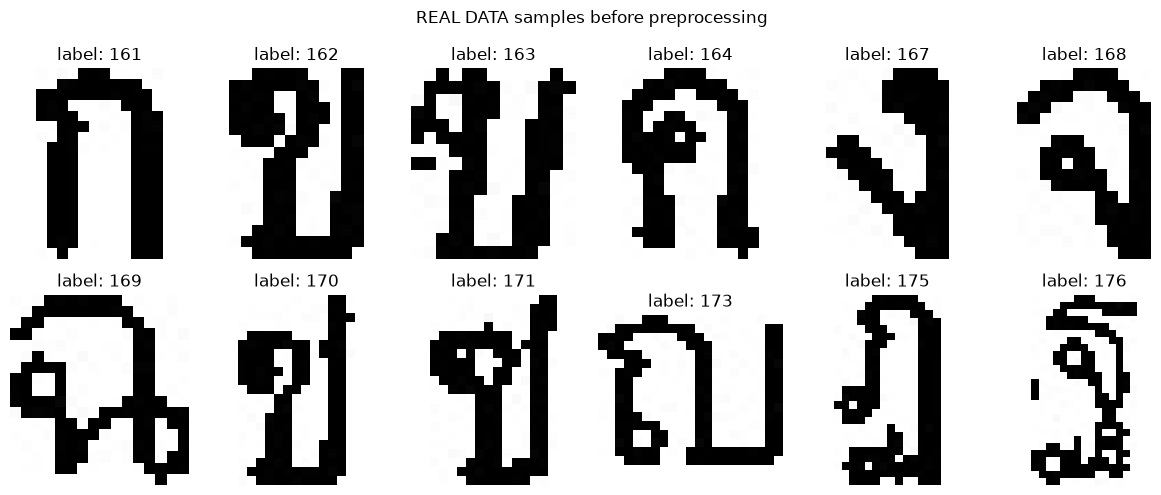

In [5]:
if MODE == "smoke":
    data_dir = results_dir / "smoke_fixture/images"
    split_dir = results_dir / "smoke_fixture/splits"
    rng = np.random.default_rng(42)
    for label in range(3):
        folder = data_dir / f"synthetic_{label}"
        folder.mkdir(parents=True, exist_ok=True)
        for i in range(10):
            pixels = rng.integers(0, 40, (40, 32, 3), dtype=np.uint8)
            pixels[:, :, label] += 180
            Image.fromarray(pixels).save(folder / f"{i:03d}.png")
    expected_classes, label_level = 3, 1
else:
    requested_data = Path(DATA_PATH).expanduser() if DATA_PATH else configured_data_dir()
    data_dir = (requested_data if requested_data.is_absolute() else project_dir / requested_data).resolve()
    requested_split = Path(SPLIT_PATH).expanduser() if SPLIT_PATH else project_dir / "data/splits"
    split_dir = (requested_split if requested_split.is_absolute() else project_dir / requested_split).resolve()
    expected_classes, label_level = EXPECTED_CLASSES, LABEL_LEVEL
    required = ["train.csv", "val.csv", "label_to_index.json", "split_meta.json"]
    if not all((split_dir / f).is_file() for f in required):
        raise FileNotFoundError("ต้องรับ split กลางครบ 4 ไฟล์ก่อน: " + str(split_dir))
    if (data_dir / ".download_incomplete").exists():
        raise RuntimeError("dataset ยังดาวน์โหลดไม่ครบ")

audit_dir = results_dir / MODE / "audit"
audit_report = audit_dataset(data_dir, audit_dir, label_level, DEFAULT_EXTENSIONS)
display(pd.Series({k: audit_report[k] for k in ["valid_images", "class_count", "corrupt_images", "label_errors", "exact_duplicate_groups"]}))
if audit_report["corrupt_images"] or audit_report["label_errors"]:
    raise ValueError("แก้ corrupt images / labels ก่อนทดลอง")
# ใช้ settings ของ split กลาง ไม่ผูก split seed กับ training seed
previous_meta = json.loads((split_dir / "split_meta.json").read_text()) if (split_dir / "split_meta.json").exists() else {}
split_meta = prepare_split(data_dir, audit_dir, split_dir,
    seed=previous_meta.get("seed", 42), val_fraction=previous_meta.get("val_fraction", 0.2),
    expected_classes=expected_classes,
    conflicting_label_policy=previous_meta.get("conflicting_label_policy", "exclude"))
train_rows, val_rows, mapping, _ = load_split(data_dir, split_dir)
if split_meta.get("train_only_classes") or {r["label"] for r in val_rows} != set(mapping):
    print("คำเตือน: คลาสที่ไม่มี validation จะไม่ถูกวัดจากภาพ validation: " + str(split_meta.get("train_only_classes", [])))
counts = pd.crosstab(pd.Series([r["label"] for r in train_rows + val_rows], name="label"),
                     ["train"] * len(train_rows) + ["validation"] * len(val_rows))
display(counts)

if MODE == "smoke":
    print("⚠️ SMOKE DATA: เป็นภาพสุ่มสำหรับตรวจระบบ ไม่ใช่ข้อมูลตัวอักษรจริง")
else:
    print("✅ REAL DATA พร้อมใช้งาน")
print("Dataset root:", data_dir)
print("โฟลเดอร์ภาพจริง:", data_dir / "round2")
print("จำนวนภาพ / คลาส:", audit_report["valid_images"], "/", audit_report["class_count"])

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
sample_rows = pd.DataFrame(train_rows).sort_values(["label", "path"]).groupby("label").head(1).head(12)
for axis, row in zip(axes.flat, sample_rows.itertuples()):
    with Image.open(data_dir / row.path) as image:
        axis.imshow(image.convert("RGB"), cmap="gray")
    axis.set_title(f"label: {row.label}")
for axis in axes.flat:
    axis.axis("off")
plt.suptitle("REAL DATA samples before preprocessing" if MODE != "smoke" else "SMOKE samples — NOT REAL DATA")
plt.tight_layout()
plt.savefig(audit_dir / "dataset_samples.png", dpi=140)
plt.show()

## 4. ล็อก protocol และ pretrained recipe

ใช้ค่าฐานเหมือน lab เดิม: freeze 2 epochs, head LR 1e-3, fine-tune LR 1e-4, AdamW, dropout 0.3,
weight decay 1e-4, augmentation/class weights ปิด, patience 5, macro F1 เลือก checkpoint
ทุกตัวใช้ RGB 224 + resize/pad + normalization เดียวกันเพื่อเทียบกับงานเดิม

**ข้อจำกัด:** pretrained recipe บางตัวคาด input/mean/std/interpolation ต่างกัน เราบันทึกความต่างใน catalog
ผลจึงตอบว่า recipe ไหนเหมาะกับ *protocol นี้* ไม่ใช่ ceiling ของแต่ละ architecture
หากจะใช้ native transforms ให้ทำการทดลองใหม่แยกตาราง ไม่แก้ transforms รายโมเดลกลางรอบ

ผลแยกด้วย mode/split/protocol hash รวม versions, code และ candidate list. รันซ้ำใช้ completed run เดิม;
run ที่ขาดกลางทางเริ่ม epoch 1 ใหม่ ไม่ได้ resume optimizer. ไม่เปิด notebook พร้อมกันใน output เดียวกัน

In [6]:
def resolve_candidate(row):
    result = dict(row)
    name = row["model"]
    if name == "custom_cnn":
        return {**result, "architecture": name, "status": "ready", "pretrained_recipe": {}}
    if not timm.is_model(name):
        return {**result, "status": "unavailable", "error": "model absent from installed timm"}
    cfg = timm.models.get_pretrained_cfg(name)
    if cfg is None or not cfg.has_weights:
        return {**result, "status": "unavailable", "error": "no registered pretrained weights"}
    name = name if "." in name or not cfg.tag else f"{name}.{cfg.tag}"
    recipe = cfg.to_dict()
    return {**result, "architecture": name, "status": "ready", "pretrained_recipe": recipe,
            "native_size": list(cfg.input_size), "native_mean": list(cfg.mean), "native_std": list(cfg.std)}

selected = candidate_table if POOL == "all" else candidate_table.query("tier == 'core'")
if ONLY_FAMILIES:
    unknown = set(ONLY_FAMILIES) - set(selected.family)
    if unknown:
        raise ValueError(f"Family ไม่อยู่ใน pool: {unknown}")
    selected = selected[selected.family.isin(ONLY_FAMILIES)]
if MODE == "smoke":
    selected = candidate_table[candidate_table.family == "ResNet"]
custom = {"family": "CustomCNN", "model": "custom_cnn", "group": "From scratch", "tier": "baseline",
          "cost": "low", "hypothesis": "baseline ที่อธิบาย convolution/pooling/loss ได้ทุกชั้น"}
catalog_rows = ([custom] if INCLUDE_CUSTOM_CNN else []) + selected.to_dict("records")
catalog = [resolve_candidate(row) for row in catalog_rows]
base_config = TrainConfig(seed=SEED, image_size=32 if MODE == "smoke" else IMAGE_SIZE,
    batch_size=8 if MODE == "smoke" else BATCH_SIZE, epochs=budget[0],
    freeze_epochs=0 if MODE == "smoke" else 2, pretrained=MODE != "smoke",
    device=DEVICE, pad_value=PAD_VALUE)
versions = {name: importlib.metadata.version(name) for name in ["torch", "torchvision", "timm", "numpy", "scikit-learn", "optuna"]}
contract = {"config": asdict(base_config), "catalog": catalog, "split_hash": split_meta["split_hash"],
    "versions": versions, "top_k": TOP_K, "seeds": list(CONFIRM_SEEDS), "budget": budget,
    "allow_partial": ALLOW_PARTIAL, "run_hpo": RUN_HPO,
    "notebook_hash": fingerprint([c["source"] for c in json.loads((project_dir / "notebooks/02-model-family-search-lab.ipynb").read_text())["cells"]]),
    "trainer_hash": fingerprint([(project_dir / "src" / f).read_text() for f in ["train.py", "split.py", "search.py"]])}
experiment_dir = results_dir / MODE / split_meta["split_hash"][:12] / fingerprint(contract)[:12]
experiment_dir.mkdir(parents=True, exist_ok=True)
save_json(experiment_dir / "protocol.json", contract)
coverage_table.to_csv(experiment_dir / "master_family_decisions.csv", index=False)
pd.DataFrame(catalog).to_csv(experiment_dir / "candidate_catalog.csv", index=False)
display(pd.DataFrame(catalog).drop(columns=["pretrained_recipe"]))
print("Screening upper bound:", len(catalog) * budget[0], "model-epochs (ไม่ใช่ชั่วโมง)")
print("Confirmation upper bound:", (TOP_K + 1) * len(CONFIRM_SEEDS) * budget[1], "model-epochs")
print("Output:", experiment_dir)

,family,model,group,tier,cost,hypothesis,architecture,status,native_size,native_mean,native_std
0,CustomCNN,custom_cnn,From scratch,baseline,low,baseline ที่อธิบาย convolution/pooling/loss ได...,custom_cnn,ready,NaN,NaN,NaN
1,ResNet,resnet18,CNN,core,low,residual connection ช่วยส่ง gradient; เป็น con...,resnet18.a1_in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
2,ResNeXt,resnext50_32x4d,CNN,core,high,grouped convolution เพิ่มทางเรียน feature เส้น...,resnext50_32x4d.a1h_in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
3,DenseNet,densenet121,CNN,core,medium,นำ feature ตื้นกลับมาใช้ ช่วยรักษาขอบ/เส้นเล็ก...,densenet121.ra_in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
4,Res2Net,res2net50_26w_4s,CNN,core,high,หลาย receptive fields ใน block เดียว ทดสอบหัวต...,res2net50_26w_4s.in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
5,ResNeSt,resnest50d,Attention CNN,core,high,split attention เลือก feature branch ที่สำคัญต...,resnest50d.in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
6,DLA,dla34,CNN,extended,medium,รวม feature หลายระดับ ทดสอบ local strokes กับ ...,dla34.in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
7,SE-ResNet,seresnet50,Attention CNN,extended,high,channel attention ถ่วงน้ำหนัก feature ที่แยกคล...,seresnet50.a1_in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
8,ECA-ResNet,ecaresnet26t,Attention CNN,extended,medium,channel attention แบบเบา เทียบประโยชน์กับต้นทุ...,ecaresnet26t.ra2_in1k,ready,"[3, 256, 256]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
9,EfficientNet,efficientnet_b0,Efficient CNN,core,low,compound scaling ให้ reference ของ accuracy ต่...,efficientnet_b0.ra_in1k,ready,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"


Screening upper bound: 246 model-epochs (ไม่ใช่ชั่วโมง)
Confirmation upper bound: 160 model-epochs
Output: /Users/thawaree.kha/kmitl-deeplearn-project1/results/model_family_search/quick/e90d3777438a/f89afe433380


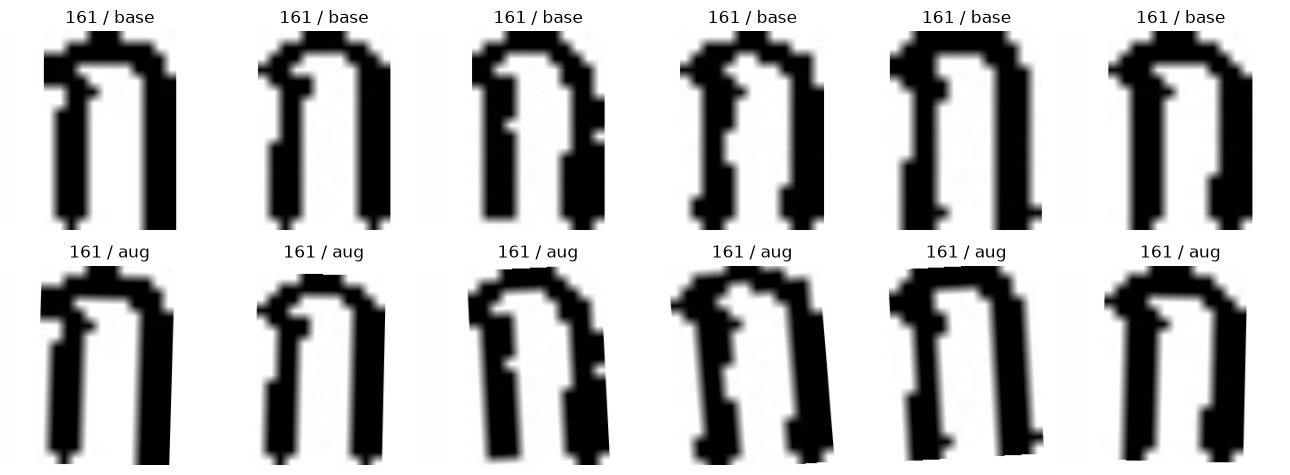

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
normal_transform = make_transform(base_config)
augmented_config = replace(base_config, augmentation=True)
augmented_transform = make_transform(augmented_config, training=True)
for i, row in enumerate(train_rows[:6]):
    with Image.open(data_dir / row["path"]) as source:
        original = source.convert("RGB")
    for j, transform in enumerate([normal_transform, augmented_transform]):
        tensor = transform(original)
        pixels = tensor.permute(1, 2, 0).numpy() * np.array(base_config.std) + np.array(base_config.mean)
        axes[j, i].imshow(pixels.clip(0, 1))
        axes[j, i].set_title(f"{row['label']} / {'aug' if j else 'base'}")
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()
plt.savefig(experiment_dir / "preprocessing_preview.png", dpi=140)
plt.show()

## 5. Preflight → เทรนทีละ candidate → บันทึกความคืบหน้าทันที

Preflight สร้างโมเดลโดย **ไม่โหลด weights** แล้วลอง forward/backward จริงที่ขนาด input/device เดียวกับ run
ตรวจ classifier, output `[batch, classes]`, finite loss และ gradients ทั้ง head-only/full network
จึงตรวจได้มากกว่าการมีชื่อใน registry แต่ยังไม่รับประกันว่าฝึกด้วย batch ใหญ่จะไม่ OOM
ดาวน์โหลด pretrained weights เฉพาะตอนเริ่ม `fit()`; ปัญหา download/OOM จะถูกบันทึกและไปตัวถัดไป

`screening_status.csv` เก็บ complete/failed/unavailable พร้อมเหตุผล; `screening.csv` มีเฉพาะผลสำเร็จ
ไม่ใช้ผล failed เป็นศูนย์ และไม่ให้คะแนนปลอม หากมีปัญหาให้แก้แล้วรัน cell นี้ซ้ำ: ตัวที่เสร็จแล้วจะ reuse
การกด interrupt หยุดทันที ไม่ถูกกลืนเป็น failed candidate

In [ ]:
def preflight(config, classes):
    device = choose_device(config.device)
    model = None
    try:
        model = build_model(config, classes, load_pretrained=False).to(device)
        count = sum(p.numel() for p in model.parameters())
        # head-only pass ตรงกับ freeze stage; full pass ตรวจ training output ด้วย
        for frozen in (True, False):
            for p in model.parameters():
                p.requires_grad_(not frozen)
            classifier = model.get_classifier()
            if not isinstance(classifier, torch.nn.Module) or not list(classifier.parameters()):
                raise TypeError("trainer requires a trainable get_classifier() module")
            for p in classifier.parameters():
                p.requires_grad_(True)
            model.eval() if frozen else model.train()
            images = torch.randn(2, 3, config.image_size, config.image_size, device=device)
            logits = model(images)
            if not isinstance(logits, torch.Tensor) or logits.shape != (2, classes):
                raise ValueError("model must return a single [batch, classes] tensor")
            loss = torch.nn.functional.cross_entropy(logits, torch.tensor([0, classes - 1], device=device))
            if not torch.isfinite(loss):
                raise FloatingPointError("non-finite preflight loss")
            loss.backward()
            grads = [p.grad for p in model.parameters() if p.grad is not None]
            if not grads or not all(torch.isfinite(g).all().item() for g in grads):
                raise FloatingPointError("missing/non-finite gradients")
            model.zero_grad(set_to_none=True)
        return count
    finally:
        del model
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()

receipts, statuses = [], []
preflight_cache_path = experiment_dir / "preflight.json"
preflight_cache = json.loads(preflight_cache_path.read_text()) if preflight_cache_path.exists() else {}
for candidate in catalog:
    status = {k: candidate[k] for k in ["family", "model", "status"]}
    if candidate["status"] != "ready":
        status["error"] = candidate.get("error", "unavailable")
    else:
        config = replace(base_config, architecture=candidate["architecture"],
                         pretrained=base_config.pretrained and candidate["model"] != "custom_cnn")
        try:
            key = fingerprint([asdict(config), len(mapping), str(choose_device(DEVICE))])
            if key not in preflight_cache:
                preflight_cache[key] = preflight(config, len(mapping))
                save_json(preflight_cache_path, preflight_cache)
            status["parameter_count"] = preflight_cache[key]
            receipt = fit(config, data_dir, split_dir, experiment_dir / "runs", phase="family_screening")
            receipts.append({**receipt, "family": candidate["family"], "group": candidate["group"],
                             "hypothesis": candidate["hypothesis"]})
            status.update(status="complete", run_id=receipt["run_id"])
        except Exception as error:
            status.update(status="failed", error=f"{type(error).__name__}: {error}")
            print("FAILED", candidate["family"], status["error"])
    statuses.append(status)
    pd.DataFrame(statuses).to_csv(experiment_dir / "screening_status.csv", index=False)
    if receipts:
        rank_runs(receipts).to_csv(experiment_dir / "screening.csv", index=False)
if not receipts:
    raise RuntimeError("ไม่มี candidate สำเร็จ ดู screening_status.csv")
screening = rank_runs(receipts)
screening["train_val_gap"] = screening.train_accuracy - screening.val_accuracy
screening.to_csv(experiment_dir / "screening.csv", index=False)
display(pd.DataFrame(statuses))
display(screening[["family", "backbone", "val_macro_f1", "val_accuracy", "minimum_per_class_recall",
                   "parameter_count", "training_seconds", "train_val_gap"]])

family_screening-custom_cnn-ff1477c61f | 1/6 | loss=1.4307 val_acc=0.7889 macro_f1=0.4054
family_screening-custom_cnn-ff1477c61f | 2/6 | loss=0.6827 val_acc=0.6491 macro_f1=0.3691
family_screening-custom_cnn-ff1477c61f | 3/6 | loss=0.4986 val_acc=0.8886 macro_f1=0.5869
family_screening-custom_cnn-ff1477c61f | 4/6 | loss=0.3980 val_acc=0.9105 macro_f1=0.6813
family_screening-custom_cnn-ff1477c61f | 5/6 | loss=0.3431 val_acc=0.9295 macro_f1=0.7226
family_screening-custom_cnn-ff1477c61f | 6/6 | loss=0.2966 val_acc=0.9255 macro_f1=0.7055


family_screening-resnet18.a1_in1k-4c0648c0bf | 1/6 | loss=1.7054 val_acc=0.8097 macro_f1=0.3699
family_screening-resnet18.a1_in1k-4c0648c0bf | 2/6 | loss=0.7538 val_acc=0.8767 macro_f1=0.5164
family_screening-resnet18.a1_in1k-4c0648c0bf | 3/6 | loss=0.4632 val_acc=0.9711 macro_f1=0.7377
family_screening-resnet18.a1_in1k-4c0648c0bf | 4/6 | loss=0.1067 val_acc=0.9781 macro_f1=0.8217
family_screening-resnet18.a1_in1k-4c0648c0bf | 5/6 | loss=0.0749 val_acc=0.9760 macro_f1=0.8565
family_screening-resnet18.a1_in1k-4c0648c0bf | 6/6 | loss=0.0569 val_acc=0.9814 macro_f1=0.8891


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/resnext50_32x4d.a1h_in1k/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/resnext50_32x4d.a1h_in1k/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/resnext50_32x4d.a1h_in1k/resolve/main/model.safetensors
Retrying in 4s [Retry 3/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/resnext50_32x4d.a1h_in1k/resolve/main/model.safetensors
Retrying in 8s [Retry 4/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/resnext50_32x4d.a1h_in1k/resolve/main/model.safetensors
Retrying in 8s [Retry 5/5].
'[Errno 8]

FAILED ResNeXt LocalEntryNotFoundError: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors
Retrying in 2s [Retry 2/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors
Retrying in 4s [Retry 3/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors
Retrying in 8s [Retry 4/5].
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/timm/densenet121.ra_in1k/resolve/main/model.safetensors
Retrying in 8s [Retry 5/5].
'[Errno 8] nodename nor servname pr

FAILED DenseNet LocalEntryNotFoundError: An error happened while trying to locate the file on the Hub and we cannot find the requested files in the local cache. Please check your connection and try again or make sure your Internet connection is on.
family_screening-res2net50_26w_4s.in1k-98eacf010d | 1/6 | loss=0.6226 val_acc=0.9143 macro_f1=0.6998
family_screening-res2net50_26w_4s.in1k-98eacf010d | 2/6 | loss=0.2582 val_acc=0.9352 macro_f1=0.7604


### ดูผลด้วยตา: ภาพจริง + เฉลย + คำทำนายของทุกโมเดล

ตารางคะแนนบอกภาพรวม ส่วนนี้แสดง **ภาพสุ่มชุดเดียวกัน** เทียบทุกโมเดลและมีปุ่มเปิดรายละเอียดรายโมเดล
เห็นภาพจริง, label เฉลย, label ที่ทำนาย, confidence และข้อความถูก/ผิดพร้อมสีเขียว/แดง
รายละเอียดมีภาพทายผิดที่มั่นใจสูง, ภาพความมั่นใจต่ำ, recall รายคลาส และคู่คลาสที่สับสน
ภาพทายผิดถูกเลือกมาเพื่อวิเคราะห์ จึงใช้ประมาณ accuracy ทั้งชุดไม่ได้

**Validation / Evaluation / Predict ต่างกันอย่างไร:** train ใช้ปรับ weights; validation ใช้วัดผลและเลือก checkpoint;
evaluation ในส่วนนี้อ่านคำทำนาย validation ทั้งชุดของ best checkpoint; predict โหลด checkpoint มาทำนายภาพทีละภาพแล้วเทียบเฉลยเมื่อมี
validation นี้เคยใช้เลือกโมเดลแล้ว จึงไม่ใช่ unseen test และ Top-3/confidence ไม่ใช่ accuracy ของภาพเดียว

รายงาน HTML ฝังภาพในไฟล์ เปิดดูภายหลังหรือส่งให้ทีมได้ ไม่ต้องเทรนใหม่และไม่ต้องมี GPU
หากชื่อคลาสเป็นรหัส เติม `DISPLAY_LABELS` ด้วย mapping ที่ตรวจแล้ว เช่น `{"class_01": "ก"}`; ไม่เดาตัวอักษรจากเลขคลาส

**ดูผลที่เทรนไว้แล้ว:** รัน cells imports และเตรียมข้อมูล/split เท่านั้น แล้วตั้ง `REVIEW_TABLE` เป็น path ของ
`screening.csv` / `backbone_screening.csv` / `confirmation_runs.csv` ที่ต้องการดู แล้วรัน cell นี้
ต้องใช้ dataset และ split ของรอบนั้น ไฟล์ checkpoint ใน receipt ต้องยังชี้ไปโฟลเดอร์ run เดิม
ตาราง confirmation แสดงแต่ละ seed แยกกัน ไม่เอาผลปนกับ screening


In [ ]:
from IPython.display import HTML
from src.visualize import validation_gallery, live_prediction_gallery, document

REVIEW_TABLE = ""  # ใส่ path CSV เพื่ออ่านผลเดิม โดยไม่รัน training cells
DISPLAY_LABELS = {}  # mapping รหัสคลาส -> อักษรไทย ที่ตรวจแล้ว; ว่าง = แสดง label เดิม
VISUAL_SAMPLE_COUNT = 8
if REVIEW_TABLE:
    review_path = Path(REVIEW_TABLE).expanduser().resolve()
    review_receipts = pd.read_csv(review_path).to_dict("records")
    review_dir = review_path.parent / (review_path.stem + "_visuals")
    review_context = "ผลที่บันทึกไว้: " + str(review_path)
else:
    review_receipts = screening.to_dict("records")
    review_dir = experiment_dir / "screening_visuals"
    review_context = MODE
if any(r["split_hash"] != split_meta["split_hash"] for r in review_receipts):
    raise ValueError("รายงานกับ split ปัจจุบันไม่ตรงกัน ให้โหลด split ของรอบนั้น")
visual_html = validation_gallery(review_receipts, data_dir, val_rows, review_dir,
    seed=SEED, sample_count=VISUAL_SAMPLE_COUNT, labels=DISPLAY_LABELS, context=review_context)
display(HTML(visual_html))
print("เปิดรายงานได้โดยไม่เทรนใหม่:", review_dir / "index.html")

# ใช้ index ด้านซ้ายเลือกโมเดลสำหรับ Top-3 ในส่วน predict ด้านล่าง
display(pd.DataFrame(review_receipts)[["backbone", "seed", "checkpoint_path"]].reset_index(names="model_index"))

## 6. ยืนยัน top candidates และ ResNet control ด้วยงบเต็ม

Screening สั้นอาจลำเอียงเข้าข้างโมเดลที่ converge เร็ว จึงยังไม่เรียกอันดับแรกว่าโมเดลดีที่สุด
ใช้ top K + ResNet18 (หากอยู่ใน pool) เปลี่ยนเฉพาะ epoch budget แล้วฝึกหลาย seed
เรียงจาก **mean macro F1** ใช้ mean accuracy เมื่อเท่ากัน แสดง std และ minimum recall ให้เห็นความเสี่ยง
เลือก checkpoint จาก **seed แรกที่กำหนดไว้** ไม่เลือก seed ที่คะแนนดีที่สุด

ถ้าบาง candidate ล้มเหลวจะหยุดก่อนประกาศผู้ชนะจนแก้และ retry; `ALLOW_PARTIAL=True` คือยอมรับว่าเป็นผลเฉพาะชุดที่สำเร็จ
ถ้าแบ่ง ONLY_FAMILIES ให้ทีม ผลยืนยันนี้เป็นผู้ชนะของ subset เท่านั้น
สอง seeds บอกความแปรปรวนเบื้องต้น ไม่ใช่หลักฐาน statistical significance

In [ ]:
failed = [row for row in statuses if row["status"] != "complete"]
if failed and not ALLOW_PARTIAL:
    raise RuntimeError("Screening ไม่ครบ: ดู screening_status.csv, แก้แล้ว retry หรือประกาศ partial ด้วย ALLOW_PARTIAL=True")
best_run = screening.iloc[0].to_dict()
selection_stage = "screening_only"
if RUN_CONFIRMATION:
    finalists = screening.head(TOP_K).to_dict("records")
    control = screening[screening.family == "ResNet"]
    if not control.empty and not any(r["family"] == "ResNet" for r in finalists):
        finalists.append(control.iloc[0].to_dict())
    seeds = (SEED,) if MODE == "smoke" else CONFIRM_SEEDS
    confirmed = []
    for candidate in finalists:
        for seed in seeds:
            config = replace(config_from_receipt(candidate), epochs=budget[1], seed=seed)
            receipt = fit(config, data_dir, split_dir, experiment_dir / "runs", phase="family_confirmation")
            confirmed.append({**receipt, "family": candidate["family"]})
            pd.DataFrame(confirmed).to_csv(experiment_dir / "confirmation_runs.csv", index=False)
    confirmation = pd.DataFrame(confirmed)
    leaderboard = confirmation.groupby("family", sort=False).agg(
        mean_macro_f1=("val_macro_f1", "mean"), std_macro_f1=("val_macro_f1", "std"),
        mean_accuracy=("val_accuracy", "mean"), worst_seed_min_recall=("minimum_per_class_recall", "min"),
        seeds=("seed", "nunique"), parameter_count=("parameter_count", "first"),
        training_seconds=("training_seconds", "sum")).reset_index()
    assert (leaderboard.seeds == len(seeds)).all()
    leaderboard = leaderboard.sort_values(["mean_macro_f1", "mean_accuracy"], ascending=False)
    leaderboard.to_csv(experiment_dir / "family_leaderboard.csv", index=False)
    winner = leaderboard.iloc[0].family
    best_run = confirmation[(confirmation.family == winner) & (confirmation.seed == seeds[0])].iloc[0].to_dict()
    selection_stage = "family_confirmation"
    display(leaderboard)
else:
    print("ยังไม่ยืนยันหลาย seed; export จะเป็น screening_only")
save_json(experiment_dir / "selection.json", {"stage": selection_stage, "mode": MODE,
    "partial": bool(failed), "families_requested": selected.family.tolist(), "run": best_run})

## 7. Optional: ทดลอง augmentation/weights และ HPO เฉพาะ family ที่ชนะ

ตั้ง `RUN_HPO=True` หากมีงบเพิ่ม: ใช้ helper เดิม เปรียบเทียบ augmentation กับ control ก่อน แล้วลอง class weights
จาก recipe ที่ได้คะแนนสูงกว่า จากนั้น Optuna จูน LR/weight decay/dropout และยืนยันเทียบ untuned control อีกครั้ง
ผลอยู่ใน `recipe_search/` แยกจาก family leaderboard และไม่ใช่เหตุผลว่าทุก family ได้รับ tuning เท่ากัน

augmentation = affine ±5°, translate 3%, scale 0.95–1.05; ไม่ flip/crop รุนแรงเพราะอาจเปลี่ยนตัวอักษร
class weights = sqrt inverse frequency แบบจำกัดเพดาน; ไม่เปิด sampler/focal/synthesis พร้อมกัน
การเลือก recipe ใช้ F1 แต่ต้องตรวจ per-class recall หลังจบด้วย หากคลาสสำคัญแย่ลงอย่าอ้างว่าดีขึ้นทุกด้าน

In [ ]:
if RUN_HPO:
    if not RUN_CONFIRMATION:
        raise ValueError("เปิด RUN_CONFIRMATION ก่อน HPO")
    recipe_dir = experiment_dir / "recipe_search"
    recipe_dir.mkdir(exist_ok=True)
    recipe_base = replace(config_from_receipt(best_run), epochs=budget[0], seed=SEED)
    ablations = run_ablations(recipe_base, data_dir, split_dir, recipe_dir)
    display(ablations[["backbone", "val_macro_f1", "minimum_per_class_recall", "config_path"]])
    tuning_config = config_from_receipt(ablations.iloc[0].to_dict())
    study = tune(tuning_config, data_dir, split_dir, recipe_dir, n_trials=2 if MODE == "smoke" else 12)
    recipe_leaderboard, best_run = confirm(tuning_config, study, data_dir, split_dir, recipe_dir,
        epochs=budget[1], seeds=(SEED,) if MODE == "smoke" else CONFIRM_SEEDS, top_k=2)
    selection_stage = "recipe_confirmation"
    display(recipe_leaderboard)

## 8. Export และตรวจว่า checkpoint ใช้จริงได้

`export/selection.json` ระบุ smoke/จริง, scope, partial และ stage ชัดเจน; smoke checkpoint ไม่ใช่โมเดลส่งงาน
ผลทั้งหมดยังเป็น validation ที่ถูกใช้เลือกโมเดลหลายครั้ง การลอง 40 ตัวเพิ่ม selection bias
ต้องประเมินกับ unseen test ที่ไม่ใช้จูนอีกครั้งก่อนกล่าวอ้าง generalization

In [ ]:
export_dir = experiment_dir / "export"
export_dir.mkdir(exist_ok=True)
shutil.copy2(best_run["checkpoint_path"], export_dir / "best_model.pt")
shutil.copy2(best_run["config_path"], export_dir / "best_config.json")
for name in ["label_to_index.json", "split_meta.json"]:
    shutil.copy2(split_dir / name, export_dir / name)
save_json(export_dir / "selection.json", {"mode": MODE, "stage": selection_stage,
    "partial": bool(failed), "families_requested": selected.family.tolist(), "best_run": best_run,
    "protocol_path": str(experiment_dir / "protocol.json")})
best_run_dir = Path(best_run["checkpoint_path"]).parent
predictions = pd.read_csv(best_run_dir / "predictions.csv", dtype={"true_label": str, "predicted_label": str})
predictor = Predictor(export_dir / "best_model.pt", device=DEVICE)
validation_paths = [data_dir / r["path"] for r in val_rows]
reloaded = predictor.predict(validation_paths, batch_size=base_config.batch_size)
assert [r["predicted_label"] for r in reloaded] == predictions.predicted_label.tolist()
print("โหลด checkpoint และทำนาย validation ตรงกับไฟล์ที่บันทึกไว้")
display(pd.DataFrame(predictor.predict([validation_paths[0]], top_k=3)[0]["top_k"]))

### เปิดดูภาพของโมเดลสุดท้าย และลองภาพของเราเอง

ส่วนแรกเป็น evaluation report ของ checkpoint ที่ export จริง ส่วนที่สองเรียก `Predictor` จริงบนภาพที่เลือก
แสดงภาพต้นฉบับ → ภาพที่โมเดลเห็นหลัง resize/pad (แปลง normalization กลับเพื่อให้ดูได้) → Top-3 → เทียบเฉลย
ภาพ validation ใช้เฉลยจาก manifest อัตโนมัติ; ภาพนอกชุดต้องใส่ `IMAGE_TRUTH` เองตาม label mapping
ไม่ตั้งเฉลยจากคำทำนายของโมเดล และไม่เอาภาพสาธิตมารวมใน validation metrics


ตั้ง `PREDICT_MODEL_INDEX` ตาม model_index ในตาราง screening เพื่อดู Top-3 ของโมเดลอื่น; `None` = โมเดลสุดท้ายที่ export

In [ ]:
final_visual_dir = experiment_dir / "final_visuals"
display(HTML(validation_gallery([best_run], data_dir, val_rows, final_visual_dir,
    seed=SEED, sample_count=VISUAL_SAMPLE_COUNT, labels=DISPLAY_LABELS, context=MODE)))

PREDICT_MODEL_INDEX = None  # None = exported model; 0, 1, ... = โมเดลจากตาราง review
if PREDICT_MODEL_INDEX is None:
    live_predictor = predictor
    live_context = MODE
else:
    if not 0 <= PREDICT_MODEL_INDEX < len(review_receipts):
        raise ValueError("model_index ไม่อยู่ในตาราง review")
    live_predictor = Predictor(Path(review_receipts[PREDICT_MODEL_INDEX]["checkpoint_path"]), device=DEVICE)
    live_context = review_context

PREDICT_IMAGES = []  # เช่น ["/absolute/path/photo.png"]; ว่าง = สุ่ม validation ไม่เกิน 8 รูป
IMAGE_TRUTH = {}  # เช่น {"/absolute/path/photo.png": "class_01"}; ไม่มีเฉลยจะไม่ตัดสินถูก/ผิด
if PREDICT_IMAGES:
    predict_paths = [Path(p).expanduser().resolve() for p in PREDICT_IMAGES]
else:
    samples = pd.DataFrame(val_rows).sort_values("path").sample(n=min(8, len(val_rows)), random_state=SEED)
    predict_paths = [data_dir / p for p in samples.path]
known_truth = {str((data_dir / r["path"]).resolve()): r["label"] for r in val_rows}
known_truth.update({str(Path(p).expanduser().resolve()): str(label) for p, label in IMAGE_TRUTH.items()})
valid_labels = set(live_predictor.labels)
if any(label not in valid_labels for label in known_truth.values()):
    raise ValueError("เฉลยต้องใช้ label ที่มีใน label_to_index.json")
live_html, live_answers = live_prediction_gallery(live_predictor, predict_paths,
    truth=known_truth, labels=DISPLAY_LABELS, context=live_context)
display(HTML(live_html))
display(live_answers.drop(columns="top3"))
live_answers.to_csv(final_visual_dir / "live_predictions.csv", index=False)
(final_visual_dir / "live_predictions.html").write_text(document("Live predictions", live_html), encoding="utf-8")
print("รายงานภาพโมเดลสุดท้าย:", final_visual_dir)


## 9. อ่าน learning curves และคู่คลาสที่สับสนก่อนสรุป

Train–validation gap เป็นเพียงตัวชี้ เพราะ train วัดขณะเปิด dropout/augmentation
ดู loss curves และ per-class metrics ร่วมกัน ค่า minimum recall ต่ำอาจเกิดจาก support น้อยให้ตรวจจำนวนภาพด้วย
ตาราง cost ใช้ training seconds รวม overhead ของ trainer (อาจรวมโหลด weights) จึงไม่ใช่ pure GPU benchmark
พารามิเตอร์น้อยไม่ได้แปลว่า latency ต่ำ และ notebook นี้ยังไม่ fuse reparameterization models

In [ ]:
best_run_dir = Path(best_run["checkpoint_path"]).parent
history = pd.read_csv(best_run_dir / "history.csv")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history.plot(x="epoch", y=["train_loss", "val_loss"], ax=axes[0])
history.plot(x="epoch", y=["train_accuracy", "val_accuracy"], ax=axes[1])
history.plot(x="epoch", y="val_macro_f1", ax=axes[2])
plt.tight_layout()
plt.savefig(experiment_dir / "learning_curves.png", dpi=140)
plt.show()

In [ ]:
confusion_table = pd.read_csv(best_run_dir / "confusion_matrix.csv", index_col=0)
fig, ax = plt.subplots(figsize=(10, 9))
plot = ax.imshow(confusion_table.to_numpy(), cmap="Blues")
fig.colorbar(plot, ax=ax)
ax.set(xlabel="Predicted class index", ylabel="True class index", title="Best checkpoint confusion matrix")
plt.tight_layout()
plt.savefig(experiment_dir / "confusion_matrix.png", dpi=140)
plt.show()

In [ ]:
predictions = pd.read_csv(best_run_dir / "predictions.csv", dtype={"true_label": str, "predicted_label": str})
errors = predictions[predictions.true_label != predictions.predicted_label].sort_values("confidence", ascending=False)
errors.to_csv(experiment_dir / "errors.csv", index=False)
confused_pairs = errors.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False).rename("count")
display(confused_pairs.head(15).to_frame())
if not errors.empty:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, (_, row) in zip(axes.flat, errors.head(8).iterrows()):
        with Image.open(data_dir / row.path) as source:
            axis.imshow(source.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label} ({row.confidence:.2f})")
    for axis in axes.flat:
        axis.axis("off")
    plt.tight_layout()
    plt.savefig(experiment_dir / "error_examples.png", dpi=140)
    plt.show()
else:
    print("ไม่พบภาพที่ทายผิดใน validation รอบนี้")

## 10. เขียนผลให้ตอบได้ว่า “ทำไมเลือกตัวนี้”

หลังได้ผลจริง เติม `experiment_notes.csv` ทีละ family:
สมมติฐาน → กลไก → ตัวแปรที่เปลี่ยน → หลักฐาน F1/accuracy/recall/เวลา → คู่คลาสที่ยังผิด → ข้อสรุป/งานต่อ
อย่ากรอก “ดีขึ้น” ก่อนมีการเทียบกับ control; ผลไม่ดีขึ้นก็เป็นคำตอบที่มีประโยชน์

ตัวอย่างคำอธิบาย: “เลือก DenseNet เพื่อทดสอบว่า feature reuse ช่วยเส้นเล็กหรือไม่ ภายใต้ split และ recipe เดียวกับ ResNet18
ผลยืนยัน mean macro F1 = … ± … เทียบ control …; คู่คลาส … ผิดลดลง/ไม่ลดลง จึง …”

**เทียบกับรอบเดิม:** ใช้ split hash, train config, pretrained tag, epochs, seed, code/dependency versions เดียวกันเท่านั้น
Notebook นี้เทรน ResNet/EfficientNet/MobileNet control ซ้ำใน protocol ปัจจุบัน จึงไม่ดึงคะแนนเก่าต่างเงื่อนไขมาปน
การ reuse มีเฉพาะผลที่ตรงใน output ของ notebook นี้ ไม่ค้น/ย้ายผลเดิมอัตโนมัติ
ถ้าอยากลองเพิ่มจากเดิมอย่างเดียว ตั้ง ONLY_FAMILIES และเก็บผลแยก ก่อนให้ผู้รวมผลตรวจ config

**ต่อจากนี้:** เลือก winner + โมเดลเล็กสำรองจากผลยืนยัน → ตรวจ confusion → ทดลองหนึ่งปัจจัย → unseen test
ส่ง protocol.json, candidate_catalog.csv, screening_status.csv, family_leaderboard.csv, confirmation_runs.csv และ export ให้ทีม
หากปิด confirmation ให้ส่ง screening.csv พร้อมระบุ screening_only

แหล่งตรวจ API/ชื่อโมเดล: [timm Quickstart](https://huggingface.co/docs/timm/quickstart),
[official model collection](https://github.com/huggingface/pytorch-image-models).
รายชื่อ/availability อ้างอิง registry ใน environment ที่รันจริง และบันทึก version ไว้ใน protocol

In [ ]:
notes_path = experiment_dir / "experiment_notes.csv"
if not notes_path.exists():
    notes = screening[["family", "backbone", "hypothesis", "val_macro_f1", "val_accuracy",
                       "minimum_per_class_recall", "parameter_count", "training_seconds"]].copy()
    notes["evidence_scope"] = "synthetic_smoke" if MODE == "smoke" else "screening_validation"
    for column in ["confused_pairs", "conclusion", "next_experiment"]:
        notes[column] = ""
    notes.to_csv(notes_path, index=False)
print("เติมข้อสรุป:", notes_path)
print("ผลทั้งหมด:", experiment_dir)
if MODE == "smoke":
    print("SMOKE ผ่านเฉพาะระบบจากภาพจำลอง: เปลี่ยน MODE เป็น quick/full เพื่อฝึกข้อมูลจริง")